# Supplementary: SVD of a real pretrained embedding matrix

Companion to `../05_eigen_svd.md`. This is the exercise from the end of that file, made runnable.

**Goal**: take an actual embedding matrix from a pretrained model, compute its singular value spectrum, and *see* what's inside — one dominant "rogue" direction plus a long, slowly-decaying tail. Compare against a random Gaussian matrix of the same shape — random matrices have a nearly flat spectrum (Marchenko-Pastur); trained matrices are heavily skewed *at the top*. That skew is the structural fingerprint of training (vs. random init).

A separate question — which we quantify below — is whether the skew is enough to make the matrix cleanly truncatable. Spoiler: for distilbert, **no**. Trained LM embeddings are *anisotropic* (one direction holds a huge share of the Frobenius energy) but **not** practically low-rank in the SVD-truncation sense. "Anisotropic" and "low-rank" are different claims; this notebook is mostly about pulling them apart.

**Setup**: needs `torch`, `matplotlib`, and `transformers`. If `transformers` isn't installed, run `pip install transformers` first (or skip Cell 2 and use the synthetic-fallback in Cell 3).

In [6]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(0)

print(f'torch: {torch.__version__}')

Matplotlib is building the font cache; this may take a moment.


torch: 2.11.0


## Load the embedding matrix

We'll grab `distilbert-base-uncased` (a ~66M parameter BERT distillation, ~30K vocab, 768 hidden dim). Its input token embedding is the matrix `W ∈ R^(30522 × 768)`.

If `transformers` isn't available, the next cell falls back to a synthetic 'embedding-like' matrix so the rest of the notebook still runs.

In [7]:
try:
    from transformers import AutoModel
    model = AutoModel.from_pretrained('distilbert-base-uncased')
    W = model.embeddings.word_embeddings.weight.detach().clone()
    source = 'distilbert-base-uncased'
except Exception as e:
    print(f'transformers not available ({e}); using synthetic fallback')
    # Synthetic 'embedding-like' matrix: low-rank structure + small noise
    V_dim = 30522
    D = 768
    true_rank = 50
    W = torch.randn(V_dim, true_rank) @ torch.randn(true_rank, D)
    W = W + 0.05 * torch.randn(V_dim, D)
    source = 'synthetic (low-rank + noise)'

print(f'source: {source}')
print(f'W.shape: {tuple(W.shape)}   ({W.shape[0] * W.shape[1] / 1e6:.1f}M params)')

/Users/yuhongsun/Library/Python/3.13/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 100/100 [00:00<00:00, 11982.01it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


source: distilbert-base-uncased
W.shape: (30522, 768)   (23.4M params)


## Compute the singular value spectrum

We only need the singular values (not U or V). PyTorch's `torch.linalg.svdvals` is the efficient form for this — it skips computing the singular vectors and returns just `σ_1 ≥ σ_2 ≥ ...`.

In [8]:
S = torch.linalg.svdvals(W)
print(f'Number of singular values: {S.shape[0]}')
print(f'σ_max:    {S[0]:.3f}')
print(f'σ_median: {S[S.shape[0] // 2]:.3f}')
print(f'σ_min:    {S[-1]:.3f}')
print(f'Condition number κ = σ_max / σ_min: {S[0] / S[-1]:.1f}')
print(f'Frobenius norm ‖W‖_F = √(Σ σ_i²) = {torch.sqrt((S ** 2).sum()):.2f}')
print(f'Spectral norm  ‖W‖_2 = σ_max     = {S[0]:.2f}')

Number of singular values: 768
σ_max:    219.382
σ_median: 5.939
σ_min:    1.254
Condition number κ = σ_max / σ_min: 174.9
Frobenius norm ‖W‖_F = √(Σ σ_i²) = 293.60
Spectral norm  ‖W‖_2 = σ_max     = 219.38


**Expected for distilbert**: σ_max in the low hundreds (here 219), σ_2 already much smaller (here ≈ 47 — note the steep drop after σ_1), σ_min ≈ 1.25, condition number ~10²–10³ (here 175). The picture is "one outlier σ_1, then a slowly-decaying bulk." Synthetic fallback: cleaner low-rank knee, smaller σ_max.

## Plot the spectrum (log scale)

The exercise's main observation: `σ_i` decays as `i` grows. On a log y-scale you'll see a sharp drop from σ_1 to σ_2, then a much gentler slope across the rest. The values span ~2 orders of magnitude — but most of that span lives in the σ_1 → σ_2 jump; the bulk of the spectrum is far flatter than the leading drop suggests.

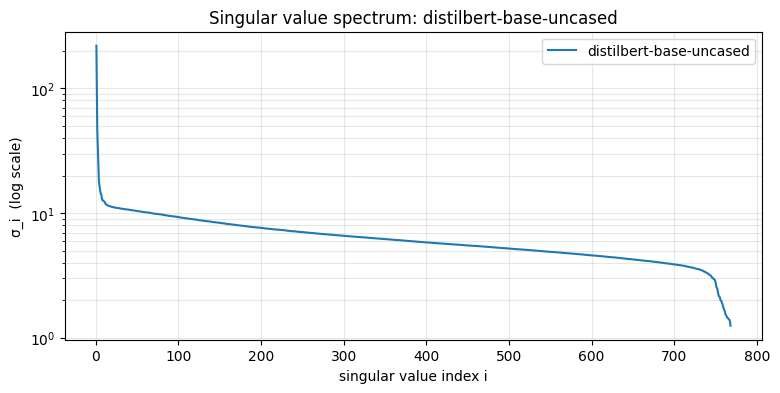

In [9]:
ranks = torch.arange(1, S.shape[0] + 1)

plt.figure(figsize=(9, 4))
plt.semilogy(ranks, S.numpy(), label=source)
plt.xlabel('singular value index i')
plt.ylabel('σ_i  (log scale)')
plt.title(f'Singular value spectrum: {source}')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.show()

## Compare to a random Gaussian matrix of the same shape

A random Gaussian matrix has a nearly flat spectrum (Marchenko-Pastur distribution): all singular values cluster in a narrow band. The trained embedding looks *very* different at the top — σ_1 sits far above the rest — but the bulk of its spectrum is closer to "flat-ish" than to "rapidly falling." The visual signature of training shows up most strongly in σ_1 and σ_2; the long tail is more uniform than you might guess.

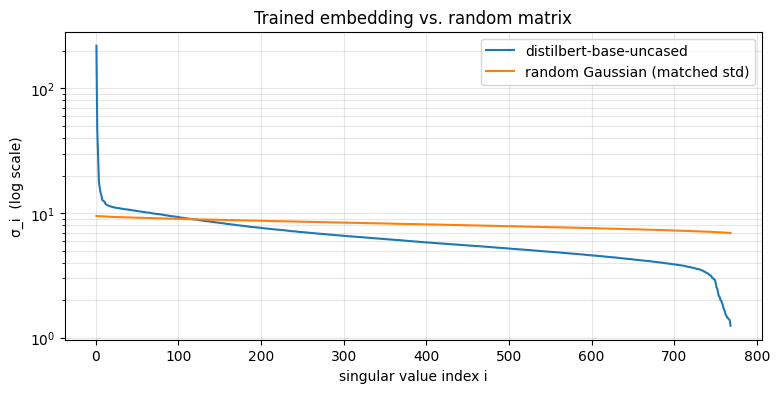

In [10]:
m, n = W.shape
# Match standard deviation to the embedding matrix for a fair comparison
W_random = torch.randn(m, n) * W.std()
S_random = torch.linalg.svdvals(W_random)

plt.figure(figsize=(9, 4))
plt.semilogy(ranks, S.numpy(),        label=source)
plt.semilogy(ranks, S_random.numpy(), label='random Gaussian (matched std)')
plt.xlabel('singular value index i')
plt.ylabel('σ_i  (log scale)')
plt.title('Trained embedding vs. random matrix')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.show()

**What you should see**: the trained-embedding curve drops sharply from σ_1 to σ_2, then runs roughly parallel to (and only modestly above) the random Gaussian curve for the rest of the spectrum. The gap between them at the *top* is the signature of learned structure (the rogue direction). The gap in the *middle* is much smaller than you'd expect from the word "low-rank" — most of the trained spectrum is not far from random in magnitude. Worth sitting with: trained ≠ "obviously low-rank" past the first few directions.

## Cumulative energy: how much of the matrix lives in the top k directions?

The Frobenius-norm energy in the top `k` singular values is `Σ_{i ≤ k} σ_i² / Σ_i σ_i²`. Plot this curve to see how many directions you need to capture e.g. 90% of the matrix's energy.

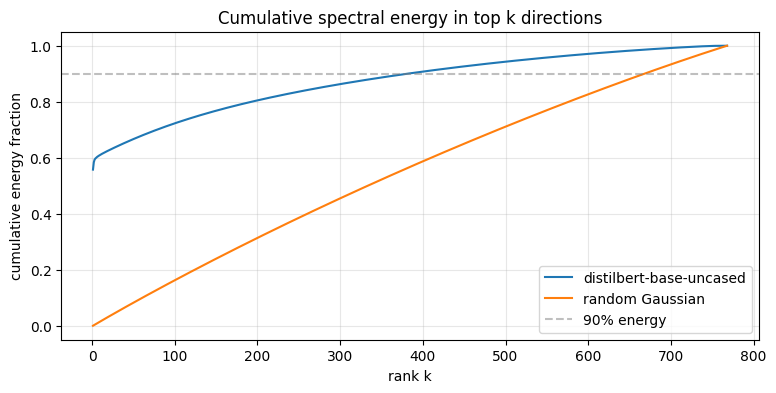


Trained matrix: 381 directions for 90% energy, 689 for 99% (out of 768)
Random matrix:  668 directions for 90% energy (out of 768)


In [11]:
energy = S ** 2
cum_energy = torch.cumsum(energy, dim=0) / energy.sum()

# Same for random
energy_r = S_random ** 2
cum_energy_r = torch.cumsum(energy_r, dim=0) / energy_r.sum()

plt.figure(figsize=(9, 4))
plt.plot(ranks, cum_energy.numpy(),   label=source)
plt.plot(ranks, cum_energy_r.numpy(), label='random Gaussian')
plt.axhline(0.9, color='gray', linestyle='--', alpha=0.5, label='90% energy')
plt.xlabel('rank k')
plt.ylabel('cumulative energy fraction')
plt.title('Cumulative spectral energy in top k directions')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# How many singular values do we need for 90% of the energy?
k_90 = int((cum_energy < 0.9).sum().item()) + 1
k_99 = int((cum_energy < 0.99).sum().item()) + 1
k_90_r = int((cum_energy_r < 0.9).sum().item()) + 1

print(f'\nTrained matrix: {k_90} directions for 90% energy, {k_99} for 99% (out of {S.shape[0]})')
print(f'Random matrix:  {k_90_r} directions for 90% energy (out of {S_random.shape[0]})')

**What you should see** (distilbert specifically):
- **σ_1 alone holds ~56% of the Frobenius energy.** One direction does the work of hundreds. This is the "rogue dimension" phenomenon — primarily a token-frequency artifact, not semantic structure.
- 70% energy → ~80 directions. 90% energy → ~380 directions. 99% energy → ~690 directions. (Out of 768.)
- Random matrix: needs ~90% of directions for 90% of the energy.

So the trained matrix is *concentrated at the very top* (σ_1) and *fat-tailed in the middle*. "Strong concentration" applies to σ_1 alone; everything after σ_1 contributes roughly comparably. The next two cells make this concrete: in terms of strict Frobenius reconstruction, you cannot truncate this matrix cleanly. Embedding spectra are skewed, but real LM embedding matrices are *not* "effectively low rank" in the way LoRA-style fine-tuning *deltas* are.

## Frobenius reconstruction error vs. rank k

By Eckart-Young, truncating to the top `k` singular values gives the optimal rank-`k` approximation. The Frobenius error is `‖W - W_k‖_F = √(Σ_{i > k} σ_i²)` — the energy in the *discarded* tail.

Plot relative error vs. `k`.

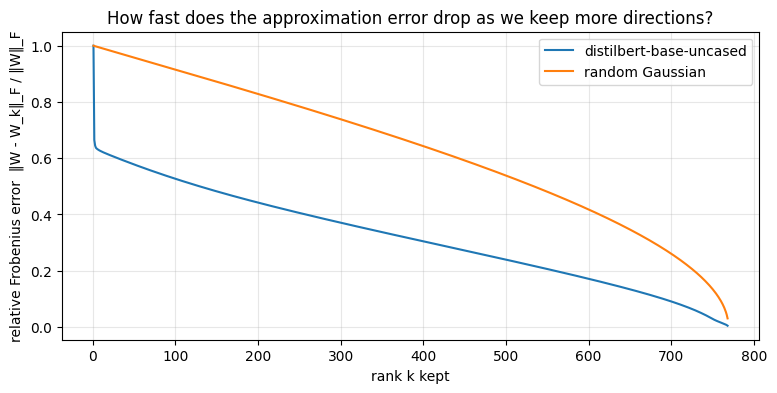

In [12]:
tail_energy = energy.flip(0).cumsum(0).flip(0)         # tail_energy[k] = sum of energy from k onward
rel_err = torch.sqrt(tail_energy / energy.sum())       # relative Frobenius error if we keep top (k-1)

tail_energy_r = energy_r.flip(0).cumsum(0).flip(0)
rel_err_r = torch.sqrt(tail_energy_r / energy_r.sum())

plt.figure(figsize=(9, 4))
plt.plot(ranks, rel_err.numpy(),   label=source)
plt.plot(ranks, rel_err_r.numpy(), label='random Gaussian')
plt.xlabel('rank k kept')
plt.ylabel('relative Frobenius error  ‖W - W_k‖_F / ‖W‖_F')
plt.title('How fast does the approximation error drop as we keep more directions?')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

**What you should see**: the trained-embedding error drops fast for the first one or two directions (capturing σ_1), then settles into a slow, near-linear descent across the long tail — meaningful error reduction past `k ≈ 50` requires keeping a lot more directions. The random curve drops linearly throughout — every direction contributes about equally, so truncating any of them costs you proportionally. The trained curve is "steeper than random" only at the very top; through the middle, the two slopes are surprisingly close.

## Storage savings from low-rank truncation

If you keep only the top `k` singular components, you store `(m + n) · k` numbers (the trimmed `U` and `V` columns) instead of `m · n` numbers (the full matrix). This is meaningfully smaller when `k « min(m, n)`.

For the embedding matrix, what's the storage win at e.g. 1% relative error?

In [13]:
for target_err in [0.10, 0.05, 0.01]:
    # Find smallest k such that rel_err[k-1] <= target_err
    # rel_err[k] is the error after keeping top k? Let me re-derive — rel_err[i] uses tail_energy[i]
    # tail_energy[i] = energy from index i onward. So if we keep top i (indices 0..i-1), error² = tail_energy[i].
    # We want smallest i such that rel_err[i] <= target_err
    above = (rel_err > target_err).sum().item()
    k = above + 1   # smallest k where the error first drops below target
    full_params = m * n
    trunc_params = (m + n) * k
    ratio = full_params / trunc_params
    print(f'For ≤{target_err*100:>4.0f}% relative error: keep top k={k:4d}  →  '
          f'{trunc_params/1e6:.2f}M params (vs {full_params/1e6:.2f}M)  →  {ratio:.1f}× smaller')

For ≤  10% relative error: keep top k= 690  →  21.59M params (vs 23.44M)  →  1.1× smaller
For ≤   5% relative error: keep top k= 736  →  23.03M params (vs 23.44M)  →  1.0× smaller
For ≤   1% relative error: keep top k= 765  →  23.94M params (vs 23.44M)  →  1.0× smaller


**Actual** (distilbert): essentially *no* compression at 1% Frobenius error — you have to keep ~99% of the directions, so the rank-`k` form has roughly the same param count as the original. Even at 10% relative Frobenius error the compression ratio is ~1×. This is the headline result: the embedding matrix is skewed but **not** truncatable in any practically useful way.

**Why this matters for the bigger picture**: it explains why production LMs *don't* compress base weights via SVD truncation. The successful low-rank techniques operate on different matrices or use different mechanics:
- **LoRA** — compresses fine-tuning *updates* (`ΔW`), which really *are* close to low-rank because they only need to nudge an already-good model.
- **ALBERT-style embedding factorization** — baked into the architecture and trained that way (`V × r`, then `r × D`), not applied as a post-hoc SVD.
- **MLA** (Multi-head Latent Attention, DeepSeek) — compresses the KV cache via a *learned* low-rank projection during training, not via truncating a pretrained matrix.
- **Quantization** — drops bits per entry (e.g., int4) rather than dropping singular directions. Doesn't care about the spectrum at all.

The takeaway: SVD truncation is the *math-optimal* answer to "rank-`k` approximation in Frobenius norm," but for trained LM weight matrices the practical compression knobs that actually work aren't shaped like SVD truncation.

## Frobenius error is only a proxy for embedding quality

A subtlety worth pausing on: everything above measures `‖W − Ŵ‖_F` — the root-sum-square of entry-wise errors. Frobenius pairs cleanly with SVD truncation (Eckart-Young gives a closed-form optimum), but it isn't what you actually care about when you ask "is this embedding good?"

For a uniformly random unit input `x`, Frobenius error answers:
```
E_x[ ‖(W − Ŵ) x‖² ] = ‖W − Ŵ‖_F² / d
```
That is, average-case behavior over uniformly random inputs, weighting every entry equally. Real embedding usage looks nothing like that:

1. **Entries are weighted equally; tokens are not.** The row for `the` (used billions of times in training) costs the same in Frobenius as the row for some near-unused token. Behaviorally these are nowhere close to equally important.
2. **Downstream code consumes *inner products*, not entries.** Attention scores `q·k`, retrieval `cos(w_i, w_j)`, LM-head logits `x · w_token^T` — all geometric. Two matrices can have small Frobenius distance and meaningfully different inner-product structure (a softmax amplifies small gaps).
3. **The dominant direction crowds out the rest.** With σ_1² ≈ 56% of Frobenius energy, getting σ_1 right is *free Frobenius credit*. A method that nails the rogue dim and trashes everything else looks great on Frobenius and behaves terribly downstream. (The "all-but-the-top" trick — *removing* σ_1 from contextual embeddings — sometimes *improves* downstream tasks, because σ_1 is largely a token-frequency artifact rather than semantic content.)
4. **Frobenius can't see direction importance.** The model uses some directions for "is this a noun," some for "is this plural," some for `the`. Frobenius treats them all the same.

What you'd actually measure for embedding *quality*:
- **Cosine-similarity preservation** between pairs of token embeddings.
- **Top-k nearest-neighbor overlap** with the original (the retrieval-relevant metric).
- **Logit-order / KL divergence at the LM head** (for tied output embeddings).
- **Downstream task loss** after substituting the compressed matrix back in (the only load-bearing metric).

Frobenius is the spherical-cow version: closed-form optimum, aligns roughly enough with reality that the *shape* of the spectrum is informative. But "10% Frobenius error" doesn't translate to "10% worse embeddings" — it could be much better or much worse depending on which directions you trashed.

## Self-check

1. Why is the singular value spectrum of a random Gaussian matrix nearly flat?
2. If you wanted a 1.5× compression of the embedding matrix at zero relative Frobenius error, would that be possible? Why or why not?
3. The condition number κ for distilbert's embedding matrix is in the hundreds (≈ 175 here). What does that say about the matrix's behavior under inversion or pseudo-inversion?
4. The embedding matrix has more rows than columns (~30K rows, 768 cols). What's the maximum possible rank? Does the spectrum suggest the matrix is at full rank — and even if it is, does that mean SVD truncation is useful on it?
5. The cumulative-energy plot shows σ_1 alone holding ~56% of the Frobenius energy. Is it correct to conclude that the embedding matrix is "essentially rank 1"?

## Answers

1. Random Gaussian matrices have no learned structure — every direction is statistically equivalent. The Marchenko-Pastur theorem makes this precise: as `m, n → ∞` with `n/m` fixed, the singular value distribution converges to a fixed shape bounded between roughly `√m - √n` and `√m + √n`. No singular value is much larger than any other; the spectrum is concentrated in a narrow band rather than spread over orders of magnitude.
2. **Lossless compression is generally impossible** unless the matrix has *exact* zero singular values (true rank deficiency). With finite-precision floats, true zeros are extremely rare. You can get *near-zero* error by keeping all but the smallest few singular values, but at zero error you essentially can't compress at all. Compression always trades off some accuracy for size.
3. κ ≈ 175 means inversion (or solving `Wx = b`) loses about 2 digits of precision and is moderately sensitive to small input perturbations. In practice this is a *minor* issue for embedding matrices because we don't typically invert them — we use them in forward passes and let autograd handle gradients. But it would matter if you tried to do least-squares fitting against the embeddings or anything that effectively requires `W^+`.
4. Max rank = `min(m, n) = 768`. The spectrum shows all 768 singular values are nonzero — *technically* full rank. The more useful observation: even though σ_max/σ_min ≈ 175, the matrix is **not** effectively low-rank in the truncation sense. The energy is concentrated at σ_1 (the rogue dim), but the long tail of medium-sized σ_i is too fat to drop — 90% of the Frobenius energy still needs ~half the directions, and 99% needs ~690 of 768. Anisotropic ≠ truncatable. The skew tells you the matrix *has structure*, not that you can throw most of it away.
5. **No.** σ_1 dominates *Frobenius* energy because Frobenius squares the singular values — one big σ crushes the contribution of many medium ones in the energy accounting. But "energy concentrated in σ_1" is not the same as "the matrix is essentially σ_1 u_1 v_1^T." Energy fraction in σ_1 = `σ_1² / Σσ² ≈ 0.56`. So the rank-1 approximation's relative Frobenius error is `√(1 − 0.56) ≈ 0.66` — a 66% reconstruction error, gigantic. And σ_1 in trained embeddings is largely a *token-frequency artifact* rather than semantic content; collapsing the matrix to its σ_1 component would erase the structure that actually does the model's work. "Frobenius energy concentrates in one direction" tells you that direction is statistically loud, not that the matrix lives on a 1-D subspace.

## Summary: why trained embeddings have skewed spectra

The skew you observed isn't an accident — it's the consequence of language structure, training dynamics, and implicit optimization biases all stacking together:

1. **Language has approximately low-rank *semantic* structure.** A small number of fundamental axes (syntax: noun/verb/plural; semantics: animals/colors/places; topic structure) explain a lot of the variation in word usage. Embeddings inherit some of this structure. (This is the LSA / word2vec / GloVe foundational insight: embeddings approximately factorize co-occurrence matrices.) Importantly: "language has low-rank semantic structure" is not the same as "the trained embedding matrix is itself low-rank" — the matrix also carries non-semantic mass (frequency, idiosyncrasy, noise) that fills out the long tail.

2. **Token frequency follows Zipf's law.** A few tokens (`the`, `of`, `a`) appear millions of times; most are rare. Frequent-token embeddings get thousands of times more gradient signal, drift far from initialization, and develop strong directions. Rare-token embeddings stay near init. Result: a few high-magnitude embeddings + a long tail of near-noise → skewed spectrum.

3. **Hub directions form from shared features.** Properties shared by thousands of words (`is plural`, `is a noun`, `denotes time`) get reinforced massively during training, becoming the top singular vectors. Word-specific idiosyncrasies live in lower singular vectors — reinforced less because fewer words share them.

4. **Anisotropy ("rogue dimension").** Trained embeddings empirically don't fill the embedding space uniformly — they cluster in a narrow cone with one or two dominant directions. This shows up as σ_1 (and sometimes σ_2) being dramatically larger than the rest — exactly what you see in the plot. This phenomenon was documented in BERT/GPT-2 by Ethayarajh 2019 and others; σ_1 is partly a frequency artifact (frequent tokens push hard in a shared direction), not pure semantic content.

5. **Implicit optimization bias.** Even without explicit regularization, gradient-based training (SGD, Adam) has an implicit bias toward low-effective-rank-like solutions at the *top* of the spectrum. Overparameterized linear networks provably converge to minimum-nuclear-norm solutions; deep networks show approximately the same tendency. This biases the top of the spectrum to be heavy without forcing the tail to zero.

### A nuance worth flagging

Looking at the storage-savings cell above: **strict-error SVD truncation of `distilbert`'s embedding matrix essentially doesn't compress it** (~1× at 1% Frobenius error). The skew is real — σ_1² holds ~56% of the Frobenius energy, σ_max/σ_min ≈ 175 — but the *shape* of the skew matters: after σ_1, the tail decays slowly and stays nontrivial for hundreds of directions. So "concentrated at the top" and "fat tail in the middle" both describe the same matrix.

The takeaway: embedding spectra are *anisotropic* (one or two directions dominate the Frobenius accounting), but trained LM embedding matrices are **not** "effectively low-rank" in the SVD-truncation sense. Anisotropy and low-rankness are different geometric properties, and most of the popular framing conflates them.

### Why this matters

The skew is a structural property of trained matrices, and the *anisotropy* it implies (rather than truncatable low-rankness) is what most of the modern toolkit actually relies on:

- **LoRA** — weight *updates* during fine-tuning are low-rank even when base weights aren't (you're already at a "good" point in weight space; the fine-tune just needs a few adjustment directions). This is a *different matrix* from the one you analyzed here.
- **Embedding factorization** (ALBERT, MorphTE) — a 30K × 768 matrix architected and trained as a 30K × 128 + 128 × 768 product. The low-rank structure is baked in from the start, not extracted via post-hoc SVD.
- **MLA** (Multi-head Latent Attention, DeepSeek) — KV cache compressed via a *trained* low-rank projection, not by truncating a pretrained matrix.
- **Quantization** — drops bits per entry; doesn't care about the spectrum's shape. This is what production LM compression actually uses on base weights.
- **Singular-value-based interpretability** — uses the top singular vectors of weight matrices as *signposts* of what a layer represents. It uses the spectrum without claiming the tail is throwaway.
- **Removing the rogue dimension** ("all-but-the-top" post-processing for contextual embeddings) — sometimes *improves* downstream tasks, because σ_1 carries frequency bias rather than semantic content. A direct application of "anisotropy isn't the same as useful low-rank structure."

The SVD spectrum tells you which directions are *statistically loud*, which is useful for many things — but the leap from "loud" to "throw away the rest" is the leap this notebook is trying to talk you out of for trained LM weights.